### Notebook for checking data points about the data and model in a checkpoint fashion to get a better idea of how to proceed.

## Checkpoint 1: Baselines

In [3]:
import os
import glob
import pandas as pd
import numpy as np

def get_latest_features_path() -> str:
    """Dynamically locates the most recent features folder inside data/04_analytics."""
    # Anchor to the directory where this script or notebook execution context runs
    root_dir = os.getcwd()
    
    # If executed from inside notebooks/ or src/modeling/, step up to project root
    if os.path.basename(root_dir) in ['notebooks', 'modeling', 'src']:
        root_dir = os.path.abspath(os.path.join(root_dir, os.path.pardir))
        if os.path.basename(root_dir) == 'src':
            root_dir = os.path.abspath(os.path.join(root_dir, os.path.pardir))

    analytics_dir = os.path.join(root_dir, 'data', '04_analytics')
    feature_folders = glob.glob(os.path.join(analytics_dir, "features_*"))
    
    if not feature_folders:
        raise FileNotFoundError(f"No feature folders found in target directory: {analytics_dir}")
        
    latest_folder = max(feature_folders, key=os.path.getctime)
    return latest_folder

def run_checkpoint_1():
    # 1. Locate and load the complete snapshot
    features_dir = get_latest_features_path()
    print(f"Loading feature snapshot from: {features_dir}")
    
    # Passing the directory directly to pandas reads all parquet partitions inside it
    df = pd.read_parquet(features_dir)
    initial_rows = len(df)
    
    # 2. Strict Point-in-Time Data Cleansing (Drop Leakage)
    leakage_cols = ['total_moves', 'opening', 'eco']
    df = df.drop(columns=[col for col in leakage_cols if col in df.columns], errors='ignore')
    
    # Eliminate rows missing foundational ranking metrics
    df = df.dropna(subset=['white_elo', 'black_elo'])
    
    # Constrain target array to definitive standard outcomes
    valid_results = ['1-0', '0-1', '1/2-1/2']
    df = df[df['result'].isin(valid_results)]
    
    # 3. Target Label Encoding (0: White Win, 1: Black Win, 2: Draw)
    target_map = {'1-0': 0, '0-1': 1, '1/2-1/2': 2}
    df['target'] = df['result'].map(target_map)
    
    # 4. Chronological Out-of-Time (OOT) Split Preparation
    df = df.sort_values('game_id').reset_index(drop=True)
    split_idx = int(len(df) * 0.85)
    
    train_df = df.iloc[:split_idx]
    test_df = df.iloc[split_idx:]
    
    # 5. Baseline 1 Evaluation: Majority Class Strategy
    majority_class = train_df['target'].mode()[0]
    baseline_1_accuracy = (test_df['target'] == majority_class).mean()
    
    # 6. Baseline 2 Evaluation: Higher Elo Wins Strategy
    test_df = test_df.copy()
    conditions = [
        test_df['white_elo'] > test_df['black_elo'],
        test_df['black_elo'] > test_df['white_elo']
    ]
    choices = [0, 1]  # Predict White win or Black win based on higher rating
    test_df['pred_higher_elo'] = np.select(conditions, choices, default=majority_class)
    baseline_2_accuracy = (test_df['target'] == test_df['pred_higher_elo']).mean()
    
    # 7. Summary Analytics
    draw_fraction = (df['target'] == 2).mean()
    
    print("\n================ CHECKPOINT 1 METRICS ================")
    print(f"Initial Row Count:         {initial_rows:,}")
    print(f"Cleaned Row Count:         {len(df):,}")
    print(f"Dropped Rows:              {initial_rows - len(df):,} ({(initial_rows - len(df)) / initial_rows * 100:.2f}%)")
    print("------------------------------------------------------")
    print("Class Distribution (Full Dataset):")
    for outcome, rate in df['result'].value_counts(normalize=True).items():
        print(f"  {outcome}: {rate*100:.2f}%")
    print(f"Draw Ceiling Fraction:     {draw_fraction*100:.2f}%")
    print("------------------------------------------------------")
    print("Out-of-Time Holdout Baselines:")
    print(f"  Baseline 1 (Majority Class):  {baseline_1_accuracy*100:.2f}%")
    print(f"  Baseline 2 (Higher Elo Wins): {baseline_2_accuracy*100:.2f}%")
    print("======================================================\n")
    
    return train_df, test_df

if __name__ == "__main__":
    train_set, test_set = run_checkpoint_1()

Loading feature snapshot from: /Users/anshumanmalhotra/Desktop/Tech_Related/Data_Engineering/chess_pipeline/data/04_analytics/features_20260701_0209

================ CHECKPOINT 1 METRICS ================
Initial Row Count:         2,137,557
Cleaned Row Count:         2,137,557
Dropped Rows:              0 (0.00%)
------------------------------------------------------
Class Distribution (Full Dataset):
  1-0: 49.96%
  0-1: 46.50%
  1/2-1/2: 3.54%
Draw Ceiling Fraction:     3.54%
------------------------------------------------------
Out-of-Time Holdout Baselines:
  Baseline 1 (Majority Class):  50.16%
  Baseline 2 (Higher Elo Wins): 63.42%



## Checkpoint 2: Checkpoint 2: Minimal Model

In [2]:
#Checking imports
import sklearn
import xgboost as xgb
print("Scikit-Learn Version:", sklearn.__version__)
print("XGBoost Version:", xgb.__version__)

Scikit-Learn Version: 1.9.0
XGBoost Version: 3.3.0


In [5]:
import os
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import accuracy_score, f1_score, log_loss, confusion_matrix

def run_checkpoint_2(train_df: pd.DataFrame, test_df: pd.DataFrame):
    print("\n================ STARTING CHECKPOINT 2 ================")
    
    # 1. Define primitive pre-game features (No engineered features yet)
    base_features = ['white_elo', 'black_elo', 'elo_diff', 'base_time', 'increment']
    categorical_features = ['game_category']
    
    # 2. Isolate Features and Targets
    # Encode categorical game_category using one-hot encoding
    X_train_raw = train_df[base_features + categorical_features]
    X_test_raw = test_df[base_features + categorical_features]
    
    X_train = pd.get_dummies(X_train_raw, columns=categorical_features, drop_first=True)
    X_test = pd.get_dummies(X_test_raw, columns=categorical_features, drop_first=True)
    
    # Align columns to guarantee identical train/test schemas after dummy encoding
    X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)
    
    y_train = train_df['target'].values
    y_test = test_df['target'].values
    
    print(f"Training features shape: {X_train.shape}")
    print(f"Evaluation features shape: {X_test.shape}")
    
    # 3. Initialize and Train Minimal Honest XGBoost Model
    # Using sensible default parameters with multi:softprob for probability tracking
    model = xgb.XGBClassifier(
        objective='multi:softprob',
        num_class=3,
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1
    )
    
    print("Training minimal XGBoost baseline model...")
    model.fit(X_train, y_train)
    print("Training complete.")
    
    # 4. Predict on Out-of-Time (OOT) Holdout Set
    preds = model.predict(X_test)
    pred_probs = model.predict_proba(X_test)
    
    # 5. Compute Rigorous Performance Metrics
    oot_accuracy = accuracy_score(y_test, preds)
    macro_f1 = f1_score(y_test, preds, average='macro')
    oot_log_loss = log_loss(y_test, pred_probs)
    cm = confusion_matrix(y_test, preds)
    
    # Calculate draw recall explicitly (Class 2)
    draw_recall = cm[2, 2] / cm[2, :].sum() if cm[2, :].sum() > 0 else 0.0
    
    # 6. Display Metrics Review
    print("\n================ CHECKPOINT 2 METRICS ================")
    print(f"OOT Holdout Accuracy:     {oot_accuracy*100:.2f}% (Vs Baseline 2: 63.42%)")
    print(f"OOT Macro F1-Score:       {macro_f1:.4f}")
    print(f"OOT Multi-class Log Loss: {oot_log_loss:.4f} (Theoretical Ceiling: 1.0986)")
    print("------------------------------------------------------")
    print("Confusion Matrix:")
    print("          Pred White | Pred Black | Pred Draw")
    print(f"Act White:   {cm[0,0]:<12} {cm[0,1]:<12} {cm[0,2]:<12}")
    print(f"Act Black:   {cm[1,0]:<12} {cm[1,1]:<12} {cm[1,2]:<12}")
    print(f"Act Draw:    {cm[2,0]:<12} {cm[2,1]:<12} {cm[2,2]:<12}")
    print("------------------------------------------------------")
    print(f"Draw Class Recall:        {draw_recall*100:.2f}%")
    print("======================================================\n")
    
    return model, X_train.columns.tolist()

# Execution syntax for your notebook or execution script:
model, feature_list = run_checkpoint_2(train_set, test_set)


================ STARTING CHECKPOINT 2 ================
Training features shape: (1816923, 9)
Evaluation features shape: (320634, 9)
Training minimal XGBoost baseline model...
Training complete.

================ CHECKPOINT 2 METRICS ================
OOT Holdout Accuracy:     63.49% (Vs Baseline 2: 63.42%)
OOT Macro F1-Score:       0.4299
OOT Multi-class Log Loss: 0.7375 (Theoretical Ceiling: 1.0986)
------------------------------------------------------
Confusion Matrix:
          Pred White | Pred Black | Pred Draw
Act White:   111797       49024        0           
Act Black:   56771        91787        0           
Act Draw:    6049         5206         0           
------------------------------------------------------
Draw Class Recall:        0.00%



## Checkpoint 3: Feature Engineering

In [6]:
import numpy as np

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df_eng = df.copy()
    
    # --- 1. THE RATING BATCH ---
    # Absolute difference tells the model the magnitude of the skill gap
    df_eng['abs_elo_diff'] = df_eng['elo_diff'].abs()
    
    # Average Elo captures the quality of the game (GM games vs Amateur games)
    df_eng['avg_elo'] = (df_eng['white_elo'] + df_eng['black_elo']) / 2
    
    # Boolean flag for the higher rated player
    df_eng['white_is_higher'] = (df_eng['white_elo'] > df_eng['black_elo']).astype(int)
    
    # The Golden Feature: Expected Win Probability for White (Standard Chess Formula)
    df_eng['elo_exp_white'] = 1 / (1 + 10 ** ((df_eng['black_elo'] - df_eng['white_elo']) / 400))
    
    # --- 2. THE TIME BATCH ---
    # Does the game have an increment? (Changes time pressure dynamics)
    df_eng['has_increment'] = (df_eng['increment'] > 0).astype(int)
    
    # Estimated total game time in seconds (Assuming an average game length of 40 moves)
    df_eng['est_total_time'] = df_eng['base_time'] + (df_eng['increment'] * 40)
    
    # Game pace ratio: How much of the game relies on increment vs base time?
    # Adding 1 to avoid division by zero
    df_eng['increment_reliance'] = (df_eng['increment'] * 40) / (df_eng['base_time'] + 1)
    
    return df_eng

# --- Execution & Evaluation ---
print("Engineering features...")
train_df_eng = engineer_features(train_set) # Assuming train_set is in memory from CP1
test_df_eng = engineer_features(test_set)   # Assuming test_set is in memory from CP1

# Define new feature list
new_numeric_features = [
    'white_elo', 'black_elo', 'elo_diff', 'base_time', 'increment',
    'abs_elo_diff', 'avg_elo', 'white_is_higher', 'elo_exp_white',
    'has_increment', 'est_total_time', 'increment_reliance'
] # 12 features
categorical_features = ['game_category'] # 13th feature

# Prepare Data
X_train_raw = train_df_eng[new_numeric_features + categorical_features]
X_test_raw = test_df_eng[new_numeric_features + categorical_features]

X_train = pd.get_dummies(X_train_raw, columns=categorical_features, drop_first=True)
X_test = pd.get_dummies(X_test_raw, columns=categorical_features, drop_first=True)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

y_train = train_df_eng['target'].values
y_test = test_df_eng['target'].values

# Retrain and Evaluate
print(f"Training XGBoost with {X_train.shape[1]} features...")
model_cp3 = xgb.XGBClassifier(
    objective='multi:softprob', num_class=3, n_estimators=100,
    max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1
)
model_cp3.fit(X_train, y_train)

# Metrics
preds = model_cp3.predict(X_test)
pred_probs = model_cp3.predict_proba(X_test)

new_accuracy = accuracy_score(y_test, preds)
new_log_loss = log_loss(y_test, pred_probs)

print("\n================ CHECKPOINT 3 METRICS ================")
print(f"Old OOT Accuracy: 63.49%  | New OOT Accuracy: {new_accuracy*100:.2f}%")
print(f"Old OOT Log Loss: 0.7375  | New OOT Log Loss: {new_log_loss:.4f}")
print("======================================================")

Engineering features...
Training XGBoost with 16 features...

================ CHECKPOINT 3 METRICS ================
Old OOT Accuracy: 63.49%  | New OOT Accuracy: 63.51%
Old OOT Log Loss: 0.7375  | New OOT Log Loss: 0.7375


## Checkpoint 4: Draw Decision

Ensure X_train, y_train, X_test, y_test are carried over from Checkpoint 3

In [7]:
import xgboost as xgb
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight

def evaluate_draw_tradeoff(X_train, y_train, X_test, y_test):
    print("================ CHECKPOINT 4: CLASS WEIGHTING ================\n")
    
    # 1. Model A: Unweighted (Control)
    print("Training Model A (Unweighted)...")
    model_a = xgb.XGBClassifier(
        objective='multi:softprob', num_class=3, n_estimators=100,
        max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1
    )
    model_a.fit(X_train, y_train)
    
    preds_a = model_a.predict(X_test)
    acc_a = accuracy_score(y_test, preds_a)
    cm_a = confusion_matrix(y_test, preds_a)
    draw_recall_a = cm_a[2, 2] / cm_a[2, :].sum() if cm_a[2, :].sum() > 0 else 0.0
    
    # 2. Compute Balanced Weights for Model B
    print("Calculating sample weights for class imbalance...")
    sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
    
    # 3. Model B: Weighted
    print("Training Model B (Weighted)...")
    model_b = xgb.XGBClassifier(
        objective='multi:softprob', num_class=3, n_estimators=100,
        max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1
    )
    model_b.fit(X_train, y_train, sample_weight=sample_weights)
    
    preds_b = model_b.predict(X_test)
    acc_b = accuracy_score(y_test, preds_b)
    cm_b = confusion_matrix(y_test, preds_b)
    draw_recall_b = cm_b[2, 2] / cm_b[2, :].sum() if cm_b[2, :].sum() > 0 else 0.0
    
    # 4. Output Comparison
    print("\n---------------- MODEL A (UNWEIGHTED) ----------------")
    print(f"Overall Accuracy:  {acc_a*100:.2f}%")
    print(f"Draw Recall:       {draw_recall_a*100:.2f}%")
    print(f"Draws Predicted:   {cm_a[:, 2].sum():,}")
    
    print("\n---------------- MODEL B (WEIGHTED) ------------------")
    print(f"Overall Accuracy:  {acc_b*100:.2f}%")
    print(f"Draw Recall:       {draw_recall_b*100:.2f}%")
    print(f"Draws Predicted:   {cm_b[:, 2].sum():,}")
    print("==============================================================\n")
    
    return model_a, model_b

# Execution
# Ensure X_train, y_train, X_test, y_test are carried over from Checkpoint 3
model_unweighted, model_weighted = evaluate_draw_tradeoff(X_train, y_train, X_test, y_test)

================ CHECKPOINT 4: CLASS WEIGHTING ================

Training Model A (Unweighted)...
Calculating sample weights for class imbalance...
Training Model B (Weighted)...

---------------- MODEL A (UNWEIGHTED) ----------------
Overall Accuracy:  63.51%
Draw Recall:       0.00%
Draws Predicted:   0

---------------- MODEL B (WEIGHTED) ------------------
Overall Accuracy:  49.80%
Draw Recall:       39.54%
Draws Predicted:   89,282



## Checkpoint 5
(Checking time sorting of the dataframes beforehand)

In [11]:
# Check the original training set variable we saved in Checkpoint 1
is_sorted = train_set['game_id'].is_monotonic_increasing
print(f"Is the dataset chronologically sorted? {is_sorted}")

Is the dataset chronologically sorted? True


In [12]:
import optuna
import xgboost as xgb
from sklearn.metrics import log_loss, accuracy_score

# 1. Enforce Time-Ordered Validation Split (Last 15% of the Training Data)
split_idx = int(len(X_train) * 0.85)

X_tune_train = X_train.iloc[:split_idx]
X_tune_val = X_train.iloc[split_idx:]

y_tune_train = y_train[:split_idx]
y_tune_val = y_train[split_idx:]

print(f"Time-Ordered Tuning Train Shape: {X_tune_train.shape}")
print(f"Time-Ordered Tuning Val Shape:   {X_tune_val.shape}")

def objective(trial):
    # 2. Expanded Hyperparameter Space focusing on Regularization
    param = {
        'objective': 'multi:softprob',
        'num_class': 3,
        'tree_method': 'hist',
        'max_depth': trial.suggest_int('max_depth', 4, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        
        # Regularization controls to lock down variance
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        
        'random_state': 42,
        'n_jobs': -1
    }
    
    model = xgb.XGBClassifier(**param)
    model.fit(X_tune_train, y_tune_train)
    
    preds_prob = model.predict_proba(X_tune_val)
    return log_loss(y_tune_val, preds_prob)

# 3. Launch the Validation-Driven Search
print("\nStarting Validation-Driven Optuna Optimization...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=40)

print(f"\nOptimized Parameters Found: {study.best_params}")

# 4. Final Re-train on Full 85% Training Set
print("\nRetraining production model on full training dataset...")
production_params = study.best_params
production_params.update({
    'objective': 'multi:softprob',
    'num_class': 3,
    'tree_method': 'hist',
    'random_state': 42,
    'n_jobs': -1
})

final_model = xgb.XGBClassifier(**production_params)
final_model.fit(X_train, y_train)

# 5. Touch the OOT Holdout Exactly Once
final_preds = final_model.predict(X_test)
final_probs = final_model.predict_proba(X_test)

final_acc = accuracy_score(y_test, final_preds)
final_ll = log_loss(y_test, final_probs)

print("\n================ CHECKPOINT 5 METRICS ================")
print(f"Optimized OOT Accuracy: {final_acc*100:.2f}% (Previous: 63.51%)")
print(f"Optimized OOT Log Loss: {final_ll:.4f} (Previous: 0.7375)")
print("======================================================")

/Users/anshumanmalhotra/Desktop/Tech_Related/Data_Engineering/chess_pipeline/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-07-05 18:18:22,115] A new study created in memory with name: no-name-0d40d68f-6605-4697-979a-27903c98df56


Time-Ordered Tuning Train Shape: (1544384, 16)
Time-Ordered Tuning Val Shape:   (272539, 16)

Starting Validation-Driven Optuna Optimization...


[I 2026-07-05 18:19:14,709] Trial 0 finished with value: 0.7427172064781189 and parameters: {'max_depth': 7, 'learning_rate': 0.011941263593953647, 'n_estimators': 150, 'subsample': 0.9864805069895816, 'colsample_bytree': 0.8138717056200238, 'min_child_weight': 3, 'gamma': 2.7937522131418477, 'reg_alpha': 1.7077473572350574, 'reg_lambda': 0.007640268080087174}. Best is trial 0 with value: 0.7427172064781189.
[I 2026-07-05 18:20:19,284] Trial 1 finished with value: 0.7379074096679688 and parameters: {'max_depth': 7, 'learning_rate': 0.0394551260657164, 'n_estimators': 357, 'subsample': 0.8622273463723406, 'colsample_bytree': 0.7818646956429672, 'min_child_weight': 7, 'gamma': 1.5672017408871153, 'reg_alpha': 0.09755637033745437, 'reg_lambda': 8.323512481856465}. Best is trial 1 with value: 0.7379074096679688.
[I 2026-07-05 18:21:11,452] Trial 2 finished with value: 0.7405922412872314 and parameters: {'max_depth': 6, 'learning_rate': 0.01164146197596325, 'n_estimators': 196, 'subsample':


Optimized Parameters Found: {'max_depth': 6, 'learning_rate': 0.035596466446371225, 'n_estimators': 384, 'subsample': 0.7908804902962066, 'colsample_bytree': 0.7880286826675434, 'min_child_weight': 1, 'gamma': 0.844551831052664, 'reg_alpha': 5.599859116894213, 'reg_lambda': 0.06496072962835824}

Retraining production model on full training dataset...

================ CHECKPOINT 5 METRICS ================
Optimized OOT Accuracy: 63.51% (Previous: 63.51%)
Optimized OOT Log Loss: 0.7374 (Previous: 0.7375)


### Keeping record of optuna params

In [14]:
# Hardcoding the exact optimized parameters discovered in Checkpoint 5
production_params = {
    'objective': 'multi:softprob',
    'num_class': 3,
    'tree_method': 'hist',
    'max_depth': 6,
    'learning_rate': 0.035596466446371225,
    'n_estimators': 384,
    'subsample': 0.7908804902962066,
    'colsample_bytree': 0.7880286826675434,
    'min_child_weight': 1,
    'gamma': 0.844551831052664,
    'reg_alpha': 5.599859116894213,
    'reg_lambda': 0.06496072962835824,
    'random_state': 42,
    'n_jobs': -1
}
print("Production parameters successfully loaded into memory.")

Production parameters successfully loaded into memory.


## Checkpoint 3.5
(with some issues with the execution about not including some features)

In [7]:
import pandas as pd
import numpy as np

def add_temporal_features(df: pd.DataFrame) -> pd.DataFrame:
    print("Engineering temporal history features...")
    df_temp = df.copy()
    
    # 1. Enforce chronological sort before any rolling calculations
    df_temp = df_temp.sort_values('game_id').reset_index(drop=True)
    
    # 2. Map outcome targets to numeric points (0=White Win, 1=Black Win, 2=Draw)
    # White gets 1.0 for a win, 0.0 for a loss, 0.5 for a draw. Black gets the inverse.
    point_map_white = {0: 1.0, 1: 0.0, 2: 0.5}
    df_temp['white_pts_earned'] = df_temp['target'].map(point_map_white)
    df_temp['black_pts_earned'] = 1.0 - df_temp['white_pts_earned']
    
    # 3. Calculate Games Prior
    # cumcount() starts at 0, natively representing games played *before* this row
    df_temp['white_games_prior'] = df_temp.groupby('white').cumcount()
    df_temp['black_games_prior'] = df_temp.groupby('black').cumcount()
    
    # 4. Strict Leakage Prevention: Shift points by 1 within the groupby
    df_temp['white_pts_shifted'] = df_temp.groupby('white')['white_pts_earned'].shift(1)
    df_temp['black_pts_shifted'] = df_temp.groupby('black')['black_pts_earned'].shift(1)
    
    # 5. Calculate Cumulative Points Prior (fill NaNs with 0 for the cumsum)
    df_temp['white_cum_pts'] = df_temp.groupby('white')['white_pts_shifted'].cumsum().fillna(0)
    df_temp['black_cum_pts'] = df_temp.groupby('black')['black_pts_shifted'].cumsum().fillna(0)
    
    # 6. Apply Bayesian Smoothing
    C = 20           # Number of dummy games
    global_avg = 0.50 # Neutral win rate prior
    
    df_temp['white_smoothed_winrate'] = (df_temp['white_cum_pts'] + (C * global_avg)) / (df_temp['white_games_prior'] + C)
    df_temp['black_smoothed_winrate'] = (df_temp['black_cum_pts'] + (C * global_avg)) / (df_temp['black_games_prior'] + C)
    
    # 7. Calculate Recent Form (Exponential Moving Average over last ~10 games)
    ema_func = lambda x: x.ewm(span=10, min_periods=1).mean()
    df_temp['white_recent_form'] = df_temp.groupby('white')['white_pts_shifted'].transform(ema_func)
    df_temp['black_recent_form'] = df_temp.groupby('black')['black_pts_shifted'].transform(ema_func)
    
    # Fill the first game's EMA (which is NaN due to the shift) with the neutral global average
    df_temp['white_recent_form'] = df_temp['white_recent_form'].fillna(global_avg)
    df_temp['black_recent_form'] = df_temp['black_recent_form'].fillna(global_avg)
    
    # 8. Cold Start Flags (Binary indicator for XGBoost)
    df_temp['white_is_first_game'] = (df_temp['white_games_prior'] == 0).astype(int)
    df_temp['black_is_first_game'] = (df_temp['black_games_prior'] == 0).astype(int)
    
    # Clean up intermediate calculation columns to keep the feature space clean
    drop_cols = ['white_pts_earned', 'black_pts_earned', 'white_pts_shifted', 'black_pts_shifted', 'white_cum_pts', 'black_cum_pts']
    df_temp = df_temp.drop(columns=drop_cols)
    
    return df_temp

# --- Execution ---
# Note: You must pass the FULL combined dataset (Train + Test) into this function
# so that test set rows inherit the cumulative history from the training set.
df_full = pd.concat([train_set, test_set]).reset_index(drop=True)
df_full_engineered = add_temporal_features(df_full)

# Re-split into train and test using the same 85% index as Checkpoint 1
split_idx = int(len(df_full_engineered) * 0.85)
new_train_df = df_full_engineered.iloc[:split_idx]
new_test_df = df_full_engineered.iloc[split_idx:]

Engineering temporal history features...


## Checkpoint 3.5
(issues updated)

In [15]:
import pandas as pd
import numpy as np

def add_temporal_features(df: pd.DataFrame) -> pd.DataFrame:
    print("Engineering temporal history features...")
    df_temp = df.copy()
    
    # 1. Enforce chronological sort before any rolling calculations
    df_temp = df_temp.sort_values('game_id').reset_index(drop=True)
    
    # 2. Map outcome targets to numeric points (0=White Win, 1=Black Win, 2=Draw)
    # White gets 1.0 for a win, 0.0 for a loss, 0.5 for a draw. Black gets the inverse.
    point_map_white = {0: 1.0, 1: 0.0, 2: 0.5}
    df_temp['white_pts_earned'] = df_temp['target'].map(point_map_white)
    df_temp['black_pts_earned'] = 1.0 - df_temp['white_pts_earned']
    
    # 3. Calculate Games Prior
    # cumcount() starts at 0, natively representing games played *before* this row
    df_temp['white_games_prior'] = df_temp.groupby('white').cumcount()
    df_temp['black_games_prior'] = df_temp.groupby('black').cumcount()
    
    # 4. Strict Leakage Prevention: Shift points by 1 within the groupby
    df_temp['white_pts_shifted'] = df_temp.groupby('white')['white_pts_earned'].shift(1)
    df_temp['black_pts_shifted'] = df_temp.groupby('black')['black_pts_earned'].shift(1)
    
    # 5. Calculate Cumulative Points Prior (fill NaNs with 0 for the cumsum)
    df_temp['white_cum_pts'] = df_temp.groupby('white')['white_pts_shifted'].cumsum().fillna(0)
    df_temp['black_cum_pts'] = df_temp.groupby('black')['black_pts_shifted'].cumsum().fillna(0)
    
    # 6. Apply Bayesian Smoothing
    C = 20           # Number of dummy games
    global_avg = 0.50 # Neutral win rate prior
    
    df_temp['white_smoothed_winrate'] = (df_temp['white_cum_pts'] + (C * global_avg)) / (df_temp['white_games_prior'] + C)
    df_temp['black_smoothed_winrate'] = (df_temp['black_cum_pts'] + (C * global_avg)) / (df_temp['black_games_prior'] + C)
    
    # 7. Calculate Recent Form (Exponential Moving Average over last ~10 games)
    ema_func = lambda x: x.ewm(span=10, min_periods=1).mean()
    df_temp['white_recent_form'] = df_temp.groupby('white')['white_pts_shifted'].transform(ema_func)
    df_temp['black_recent_form'] = df_temp.groupby('black')['black_pts_shifted'].transform(ema_func)
    
    # Fill the first game's EMA (which is NaN due to the shift) with the neutral global average
    df_temp['white_recent_form'] = df_temp['white_recent_form'].fillna(global_avg)
    df_temp['black_recent_form'] = df_temp['black_recent_form'].fillna(global_avg)
    
    # 8. Cold Start Flags (Binary indicator for XGBoost)
    df_temp['white_is_first_game'] = (df_temp['white_games_prior'] == 0).astype(int)
    df_temp['black_is_first_game'] = (df_temp['black_games_prior'] == 0).astype(int)
    
    # Clean up intermediate calculation columns to keep the feature space clean
    drop_cols = ['white_pts_earned', 'black_pts_earned', 'white_pts_shifted', 'black_pts_shifted', 'white_cum_pts', 'black_cum_pts']
    df_temp = df_temp.drop(columns=drop_cols)
    
    return df_temp

# 1. Combine the datasets that ALREADY possess Checkpoint 3 features
df_full = pd.concat([train_df_eng, test_df_eng]).reset_index(drop=True)

# 2. Apply the Checkpoint 3.5 Temporal Features
df_full_engineered = add_temporal_features(df_full)

# 3. Re-split into train and test using the exact 85% index
split_idx = int(len(df_full_engineered) * 0.85)
new_train_df = df_full_engineered.iloc[:split_idx]
new_test_df = df_full_engineered.iloc[split_idx:]

Engineering temporal history features...


In [16]:
import pandas as pd
import xgboost as xgb
from sklearn.metrics import accuracy_score, log_loss

# 1. Define the complete feature set
base_features = [
    'white_elo', 'black_elo', 'elo_diff', 'base_time', 'increment',
    'abs_elo_diff', 'avg_elo', 'white_is_higher', 'elo_exp_white',
    'has_increment', 'est_total_time', 'increment_reliance'
]

temporal_features = [
    'white_smoothed_winrate', 'black_smoothed_winrate', 
    'white_recent_form', 'black_recent_form', 
    'white_is_first_game', 'black_is_first_game'
]

categorical_features = ['game_category']
all_features = base_features + temporal_features + categorical_features

# 2. Extract features and target arrays
X_train_raw = new_train_df[all_features]
X_test_raw = new_test_df[all_features]

y_train_new = new_train_df['target'].values
y_test_new = new_test_df['target'].values

# 3. Apply dummy encoding and align schemas
X_train_new = pd.get_dummies(X_train_raw, columns=categorical_features, drop_first=True)
X_test_new = pd.get_dummies(X_test_raw, columns=categorical_features, drop_first=True)
X_train_new, X_test_new = X_train_new.align(X_test_new, join='left', axis=1, fill_value=0)

# 4. Train the model using the parameters from Checkpoint 5
print(f"Training XGBoost on {X_train_new.shape[1]} features...")
# Using production_params dictionary generated during the Optuna study
model_cp3_5 = xgb.XGBClassifier(**production_params)
model_cp3_5.fit(X_train_new, y_train_new)

# 5. Generate predictions
preds_new = model_cp3_5.predict(X_test_new)
probs_new = model_cp3_5.predict_proba(X_test_new)

# 6. Calculate metrics
acc_new = accuracy_score(y_test_new, preds_new)
ll_new = log_loss(y_test_new, probs_new)

# 7. Print evaluation output
print("\n================ CHECKPOINT 3.5 METRICS ================")
print(f"Previous CP5 Accuracy:  63.51%")
print(f"New Model Accuracy:     {acc_new*100:.2f}%")
print("--------------------------------------------------------")
print(f"Previous CP5 Log Loss:  0.7374")
print(f"New Model Log Loss:     {ll_new:.4f}")
print("========================================================")

Training XGBoost on 22 features...

================ CHECKPOINT 3.5 METRICS ================
Previous CP5 Accuracy:  63.51%
New Model Accuracy:     63.75%
--------------------------------------------------------
Previous CP5 Log Loss:  0.7374
New Model Log Loss:     0.7341


## Checkpoint 6

================ STARTING CHECKPOINT 6 ================

--- Probability Reliability (Brier Scores) ---
White Win Confidence Error:  0.2127
Black Win Confidence Error:  0.2117

Calculating SHAP values (subsampling 10,000 rows)...

--- Top 12 Features by Numerical SHAP Impact ---
elo_diff                  : 0.5312
abs_elo_diff              : 0.1930
est_total_time            : 0.1621
avg_elo                   : 0.1390
black_smoothed_winrate    : 0.0989
elo_exp_white             : 0.0893
white_smoothed_winrate    : 0.0861
black_elo                 : 0.0506
white_elo                 : 0.0490
white_recent_form         : 0.0428
base_time                 : 0.0415
black_recent_form         : 0.0324
--------------------------------------------------

Generating SHAP Global Summary Plot...


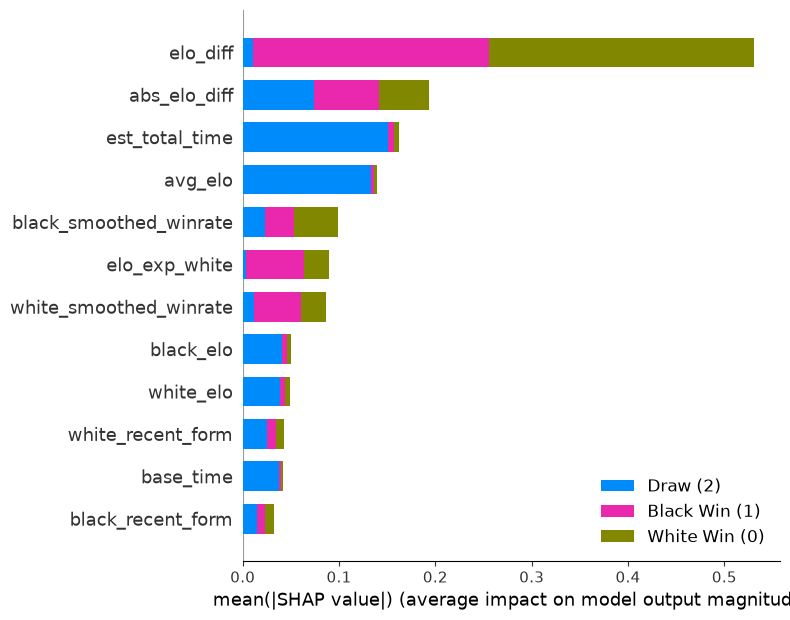

In [34]:
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import brier_score_loss
import numpy as np
import pandas as pd

def run_checkpoint_6(model, X_test, y_test, probs):
    print("================ STARTING CHECKPOINT 6 ================\n")
    
    # 1. Brier Score (Calibration Metric)
    brier_white = brier_score_loss((y_test == 0).astype(int), probs[:, 0])
    brier_black = brier_score_loss((y_test == 1).astype(int), probs[:, 1])
    
    print("--- Probability Reliability (Brier Scores) ---")
    print(f"White Win Confidence Error:  {brier_white:.4f}")
    print(f"Black Win Confidence Error:  {brier_black:.4f}\n")
    
    # 2. SHAP TreeExplainer
    print("Calculating SHAP values (subsampling 10,000 rows)...")
    X_sample = X_test.sample(n=10000, random_state=42)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)
    
    # 3. Extract and Print Numerical SHAP Values
    feature_names = X_sample.columns
    
    # Handle SHAP's output format (list of arrays for multi-class XGBoost)
    if isinstance(shap_values, list):
        # Calculate mean absolute impact across all samples, then sum across the 3 classes
        mean_abs_shap = np.sum([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
    else:
        # Fallback if SHAP returns a 3D array (samples, features, classes)
        mean_abs_shap = np.abs(shap_values).mean(axis=0).sum(axis=1)

    # Build a DataFrame to display the numbers cleanly
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Global_SHAP_Impact': mean_abs_shap
    }).sort_values(by='Global_SHAP_Impact', ascending=False)
    
    print("\n--- Top 12 Features by Numerical SHAP Impact ---")
    for idx, row in importance_df.head(12).iterrows():
        print(f"{row['Feature']:<25} : {row['Global_SHAP_Impact']:.4f}")
    print("-" * 50 + "\n")
    
    # 4. Global Feature Importance Plot
    print("Generating SHAP Global Summary Plot...")
    plt.figure(figsize=(12, 8))
    class_labels = ["White Win (0)", "Black Win (1)", "Draw (2)"]
    
    shap.summary_plot(
        shap_values, 
        X_sample, 
        plot_type="bar", 
        class_names=class_labels,
        max_display=12,
        show=True
    )
    print("========================================================")

# --- Execution ---
run_checkpoint_6(model_cp3_5, X_test_new, y_test_new, probs_new)

## Final check for the model

================ STARTING CHECKPOINT 6 ================

--- Active Model Parameters (Optuna Verification) ---
max_depth           : 6
learning_rate       : 0.035596466446371225
n_estimators        : 384
subsample           : 0.7908804902962066
colsample_bytree    : 0.7880286826675434
min_child_weight    : 1
gamma               : 0.844551831052664
reg_alpha           : 5.599859116894213
reg_lambda          : 0.06496072962835824
tree_method         : hist
-----------------------------------------------------

--- Probability Reliability (Brier Scores) ---
White Win Confidence Error:  0.2127
Black Win Confidence Error:  0.2117

Calculating SHAP values (subsampling 10,000 rows)...

--- Top 16 Features by Numerical SHAP Impact ---
elo_diff                  : 0.5312
abs_elo_diff              : 0.1930
est_total_time            : 0.1621
avg_elo                   : 0.1390
black_smoothed_winrate    : 0.0989
elo_exp_white             : 0.0893
white_smoothed_winrate    : 0.0861
black_elo         

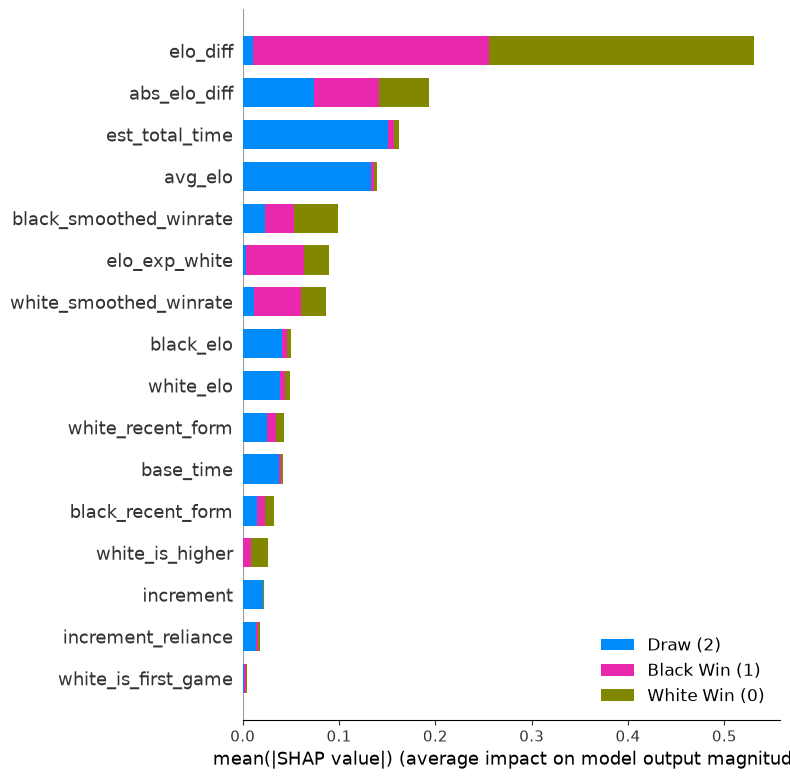

In [17]:
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import brier_score_loss
import numpy as np
import pandas as pd

def run_checkpoint_6(model, X_test, y_test, probs):
    print("================ STARTING CHECKPOINT 6 ================\n")
    
    # 0. Active Hyperparameter Audit
    print("--- Active Model Parameters (Optuna Verification) ---")
    active_params = model.get_params()
    
    # The specific parameters we asked Optuna to tune in CP5
    tuned_keys = [
        'max_depth', 'learning_rate', 'n_estimators', 
        'subsample', 'colsample_bytree', 'min_child_weight', 
        'gamma', 'reg_alpha', 'reg_lambda', 'tree_method'
    ]
    
    for key in tuned_keys:
        if key in active_params:
            print(f"{key:<20}: {active_params[key]}")
    print("-" * 53 + "\n")
    
    # 1. Brier Score (Calibration Metric)
    brier_white = brier_score_loss((y_test == 0).astype(int), probs[:, 0])
    brier_black = brier_score_loss((y_test == 1).astype(int), probs[:, 1])
    
    print("--- Probability Reliability (Brier Scores) ---")
    print(f"White Win Confidence Error:  {brier_white:.4f}")
    print(f"Black Win Confidence Error:  {brier_black:.4f}\n")
    
    # 2. SHAP TreeExplainer
    print("Calculating SHAP values (subsampling 10,000 rows)...")
    X_sample = X_test.sample(n=10000, random_state=42)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)
    
    # 3. Extract and Print Numerical SHAP Values
    feature_names = X_sample.columns
    
    if isinstance(shap_values, list):
        mean_abs_shap = np.sum([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
    else:
        mean_abs_shap = np.abs(shap_values).mean(axis=0).sum(axis=1)

    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Global_SHAP_Impact': mean_abs_shap
    }).sort_values(by='Global_SHAP_Impact', ascending=False)
    
    print("\n--- Top 16 Features by Numerical SHAP Impact ---")
    for idx, row in importance_df.head(16).iterrows():
        print(f"{row['Feature']:<25} : {row['Global_SHAP_Impact']:.4f}")
    print("-" * 50 + "\n")
    
    # 4. Global Feature Importance Plot
    print("Generating SHAP Global Summary Plot...")
    plt.figure(figsize=(12, 8))
    class_labels = ["White Win (0)", "Black Win (1)", "Draw (2)"]
    
    shap.summary_plot(
        shap_values, 
        X_sample, 
        plot_type="bar", 
        class_names=class_labels,
        max_display=16,
        show=True
    )
    print("========================================================")

# --- Execution ---
run_checkpoint_6(model_cp3_5, X_test_new, y_test_new, probs_new)

## Model serialization

In [18]:
import joblib
import os

# Ensure the directory exists
os.makedirs('../saved_models', exist_ok=True)

# Save the final optimized model
joblib.dump(model_cp3_5, '../saved_models/xgb_checkpoint3_5.joblib')
print("Model saved to saved_models/xgb_checkpoint3_5.joblib")

Model saved to saved_models/xgb_checkpoint3_5.joblib
